In [43]:
# =========================
# CELL 1: IMPORTS
# =========================
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
 
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
 
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

In [44]:
# =========================
# CELL 2: LOAD CSV
# =========================
TRAIN_CSV = Path("../data/processed/train.csv")
VAL_CSV   = Path("../data/processed/validation.csv")
 
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
 
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
train_df.head()

Train shape: (2684, 3)
Validation shape: (671, 3)


,filepath,label,split
0,data/processed/train/BrownSpot/IMG_20190420_19...,BrownSpot,train
1,data/processed/train/BrownSpot/IMG_20190420_19...,BrownSpot,train
2,data/processed/train/BrownSpot/IMG_20190420_19...,BrownSpot,train
3,data/processed/train/BrownSpot/IMG_20190420_19...,BrownSpot,train
4,data/processed/train/BrownSpot/IMG_20190420_19...,BrownSpot,train


In [45]:
# =========================
# CELL 3: FIX FILEPATHS + DROP MISSING
# =========================
train_df["filepath"] = train_df["filepath"].str.replace(
    "data/processed/train", "data/raw/RiceLeafs/train", regex=False
)
val_df["filepath"] = val_df["filepath"].str.replace(
    "data/processed/validation", "data/raw/RiceLeafs/validation", regex=False
)
 
# Build full paths relative to notebook location
train_df["full_path"] = train_df["filepath"].apply(lambda p: os.path.join("..", p))
val_df["full_path"]   = val_df["filepath"].apply(lambda p: os.path.join("..", p))
 
# Drop rows where file does not exist
train_df = train_df[train_df["full_path"].apply(os.path.exists)].reset_index(drop=True)
val_df   = val_df[val_df["full_path"].apply(os.path.exists)].reset_index(drop=True)
 
print("Train after dropping missing:", train_df.shape)
print("Val after dropping missing:  ", val_df.shape)
train_df.head()

Train after dropping missing: (2684, 4)
Val after dropping missing:   (671, 4)


,filepath,label,split,full_path
0,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train,..\data/raw/RiceLeafs/train/BrownSpot/IMG_2019...
1,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train,..\data/raw/RiceLeafs/train/BrownSpot/IMG_2019...
2,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train,..\data/raw/RiceLeafs/train/BrownSpot/IMG_2019...
3,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train,..\data/raw/RiceLeafs/train/BrownSpot/IMG_2019...
4,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train,..\data/raw/RiceLeafs/train/BrownSpot/IMG_2019...


In [46]:
# =========================
# CELL 4: CHECK CLASS DISTRIBUTION
# =========================
print("Train class distribution:")
print(train_df["label"].value_counts())
print("\nValidation class distribution:")
print(val_df["label"].value_counts())

Train class distribution:
label
Healthy      1191
LeafBlast     623
Hispa         452
BrownSpot     418
Name: count, dtype: int64

Validation class distribution:
label
Healthy      297
LeafBlast    156
Hispa        113
BrownSpot    105
Name: count, dtype: int64


In [47]:
# =========================
# CELL 5: LABEL ENCODING
# =========================
label_encoder = LabelEncoder()
 
y_train = label_encoder.fit_transform(train_df["label"])
y_val   = label_encoder.transform(val_df["label"])
 
class_names = label_encoder.classes_
num_classes = len(class_names)
 
print("Classes:", class_names)
print("Num classes:", num_classes)
print("y_train shape:", y_train.shape)
print("y_val shape:  ", y_val.shape)

Classes: ['BrownSpot' 'Healthy' 'Hispa' 'LeafBlast']
Num classes: 4
y_train shape: (2684,)
y_val shape:   (671,)


In [48]:
# =========================
# CELL 6: CLASS WEIGHTS
# =========================
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {i: w for i, w in enumerate(class_weights_array)}
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.605263157894737), 1: np.float64(0.563392107472712), 2: np.float64(1.4845132743362832), 3: np.float64(1.0770465489566614)}


In [49]:
# =========================
# CELL 7: tf.data PIPELINE (IMPROVED)
# =========================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_paths = train_df["full_path"].values
val_paths = val_df["full_path"].values

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)  # works for jpg/png/webp
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    return img, label

def augment_image(img, label):
    # gentler augmentation for leaf disease detection
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.10)
    img = tf.image.random_contrast(img, lower=0.90, upper=1.10)
    return img, label

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_paths, y_train))
    .shuffle(len(train_paths), seed=42, reshuffle_each_iteration=True)
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .map(augment_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_paths, y_val))
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("Datasets ready.")

Datasets ready.


In [50]:
# =========================
# CELL 8: BUILD MODEL
# =========================
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False
 
inputs  = layers.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.7)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
 
model = models.Model(inputs, outputs)
 
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",   # labels are integers, not one-hot
    metrics=["accuracy"]
)
 
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,059,815 (15.49 MB)

 Trainable params: 7,684 (30.02 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [51]:
# =========================
# CELL 9: CALLBACKS (IMPROVED)
# =========================
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_efficientnetb0.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [52]:
# =========================
# CELL 10: FIRST TRAINING PHASE
# =========================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15


84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2960 - loss: 2.4892
Epoch 1: val_loss improved from None to 1.30065, saving model to best_efficientnetb0.keras

Epoch 1: finished saving model to best_efficientnetb0.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 219s 2s/step - accuracy: 0.2955 - loss: 2.3933 - val_accuracy: 0.4009 - val_loss: 1.3007 - learning_rate: 1.0000e-04
Epoch 2/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3221 - loss: 2.1677
Epoch 2: val_loss did not improve from 1.30065
84/84 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.3227 - loss: 2.1498 - val_accuracy: 0.3845 - val_loss: 1.3187 - learning_rate: 1.0000e-04
Epoch 3/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3395 - loss: 2.0508
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.

Epoch 3: val_loss did not improve from 1.30065
84/84 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.3573 - loss: 1.9724 - val_accuracy: 0.3577 - val_loss: 1.3741 - learning_rate: 1.0000e-04
Epoch 

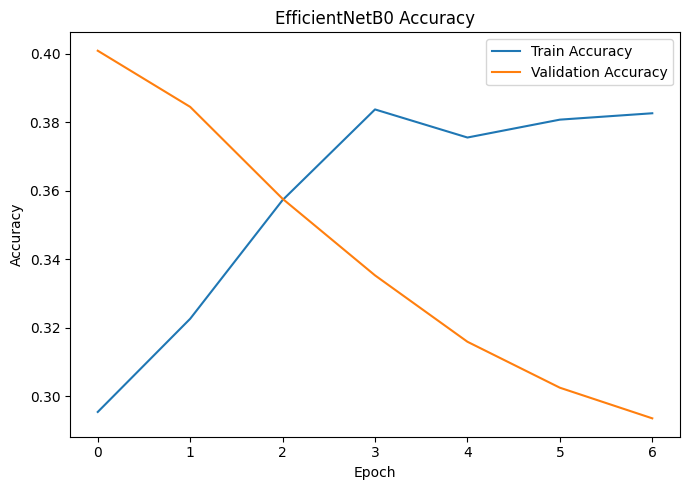

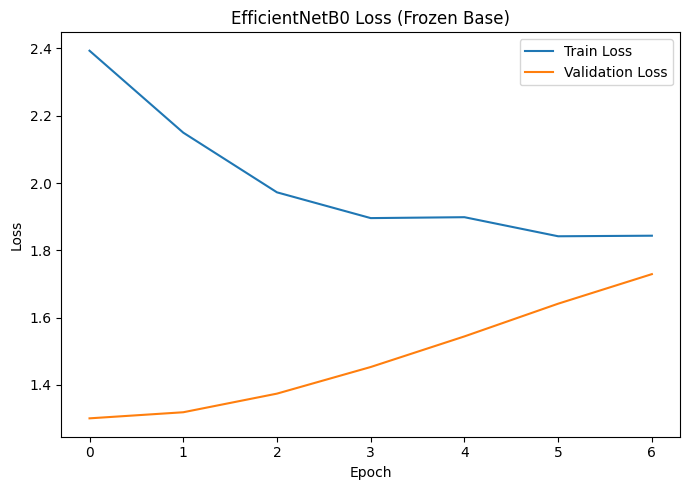

In [53]:
# =========================
# CELL 11: LEARNING CURVES — FIRST PHASE
# =========================
plt.figure(figsize=(7, 5))
plt.plot(history.history["accuracy"],     label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("EfficientNetB0 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()
 
plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"],     label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("EfficientNetB0 Loss (Frozen Base)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
# =========================
# CELL 12: FINE-TUNING PHASE (unfreeze last 50 layers)
# =========================
base_model.trainable = True
 
for layer in base_model.layers[:-50]:
    layer.trainable = False
 
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
 
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    initial_epoch=history.epoch[-1] + 1,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 8/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2522 - loss: 2.7340
Epoch 8: val_loss improved from 1.30065 to 1.28406, saving model to best_efficientnetb0.keras

Epoch 8: finished saving model to best_efficientnetb0.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 306s 3s/step - accuracy: 0.2604 - loss: 2.7194 - val_accuracy: 0.4054 - val_loss: 1.2841 - learning_rate: 1.0000e-05
Epoch 9/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3054 - loss: 2.4643
Epoch 9: val_loss did not improve from 1.28406
84/84 ━━━━━━━━━━━━━━━━━━━━ 213s 3s/step - accuracy: 0.3055 - loss: 2.4726 - val_accuracy: 0.3905 - val_loss: 1.3739 - learning_rate: 1.0000e-05
Epoch 10/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3586 - loss: 2.2377
Epoch 10: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 10: val_loss did not improve from 1.28406
84/84 ━━━━━━━━━━━━━━━━━━━━ 209s 2s/step - accuracy: 0.3577 - loss: 2.2029 - val_accuracy: 0.3726 - val_loss: 1.5024 - learning_rate: 

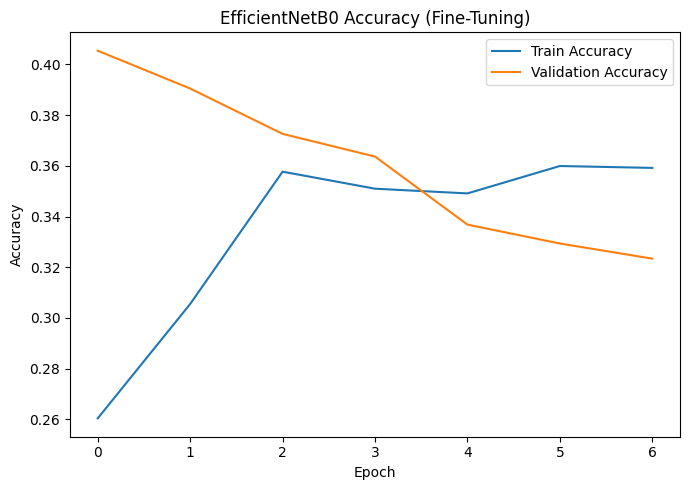

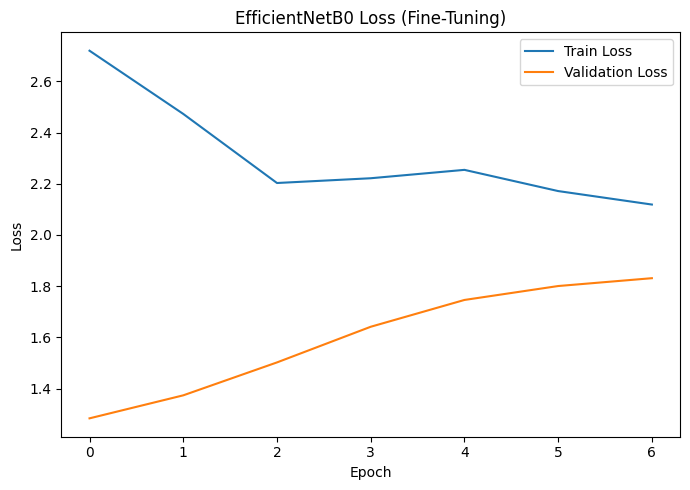

In [56]:
# =========================
# CELL 13: LEARNING CURVES — FINE TUNING
# =========================
plt.figure(figsize=(7, 5))
plt.plot(fine_tune_history.history["accuracy"],     label="Train Accuracy")
plt.plot(fine_tune_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("EfficientNetB0 Accuracy (Fine-Tuning)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()
 
plt.figure(figsize=(7, 5))
plt.plot(fine_tune_history.history["loss"],     label="Train Loss")
plt.plot(fine_tune_history.history["val_loss"], label="Validation Loss")
plt.title("EfficientNetB0 Loss (Fine-Tuning)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [57]:
# =========================
# CELL 14: EVALUATION
# =========================
val_probs = model.predict(val_ds, verbose=1)
val_pred  = np.argmax(val_probs, axis=1)
 
# Get true labels from dataset (in order, since shuffle=False on val_ds)
y_val_true = np.concatenate([y for _, y in val_ds], axis=0)
 
eff_acc = accuracy_score(y_val_true, val_pred)
eff_f1  = f1_score(y_val_true, val_pred, average="macro")
 
print("EfficientNetB0 Accuracy:", round(eff_acc, 4))
print("EfficientNetB0 Macro-F1:", round(eff_f1, 4))

21/21 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step 
EfficientNetB0 Accuracy: 0.4054
EfficientNetB0 Macro-F1: 0.3159


In [58]:
# =========================
# CELL 15: CLASSIFICATION REPORT
# =========================
print(classification_report(y_val_true, val_pred, target_names=class_names))

              precision    recall  f1-score   support

   BrownSpot       0.20      0.23      0.21       105
     Healthy       0.53      0.66      0.59       297
       Hispa       0.15      0.15      0.15       113
   LeafBlast       0.51      0.22      0.31       156

    accuracy                           0.41       671
   macro avg       0.35      0.32      0.32       671
weighted avg       0.41      0.41      0.39       671



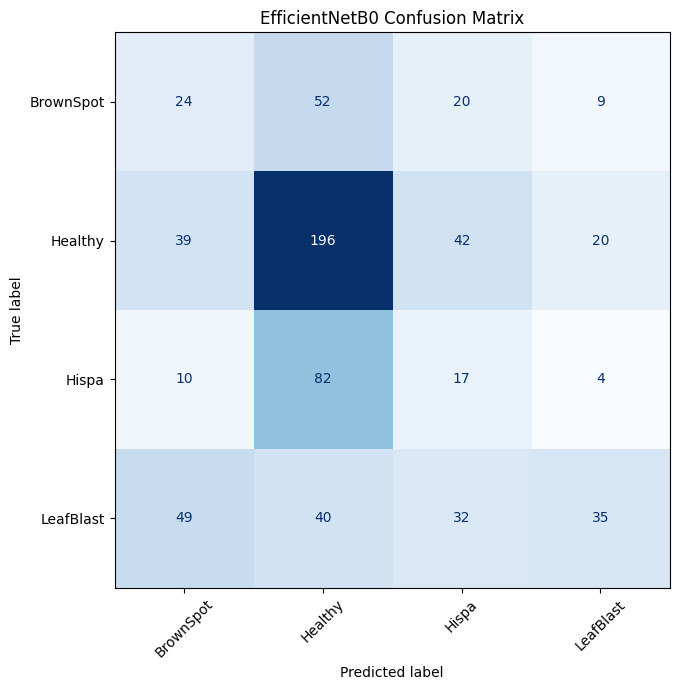

In [59]:
# =========================
# CELL 16: CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_val_true, val_pred)
 
fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("EfficientNetB0 Confusion Matrix")
plt.tight_layout()
plt.show()

In [61]:
# =========================
# CELL 17: RESULTS TABLE
# =========================
results_df = pd.DataFrame({
    "Model":    ["EfficientNetB0"],
    "Accuracy": [eff_acc],
    "Macro-F1": [eff_f1]
})
 
results_df

,Model,Accuracy,Macro-F1
0,EfficientNetB0,0.405365,0.315861
